# PandaX-4T S1/S2 cut acceptance projected to NR energy

The selection (quality-cut) acceptance is applied in the chain on the *observables* $Q_{S1}$ and $Q_{S2b}$ via appletree's `S1CutAccept` / `S2CutAccept` (maps `s1_cut_acc` / `s2_cut_acc`, PRD Fig. 12), combined by `EffPandaX4T` into `eff = cut_acc_s1 * cut_acc_s2`. To check the handling is correct we **project** this per-event acceptance onto NR *energy*: simulate many NR events from a uniform energy spectrum through the full P4-NEST + reconstruction chain, then for each energy bin take the mean of `eff`. The result is the quality-cut acceptance $\epsilon_q(\xi_{nr})$, to be compared with the **quality** curve of PRD 110 023029 Fig. 15.

Run0 and Run1 use different cut-acceptance maps (and fields / $g_1,g_2$), so both are projected. The S1-only and S2-only acceptances are shown too, to see which cut drives the low-energy rolloff.

In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import appletree as apt
import diamx
from diamx.appletree import get_file_path_diamx
from diamx.appletree.components.pandax4t import NRPandaX4T

DATA = os.path.join(os.path.dirname(diamx.__file__), 'data')
N_EVENTS = 4_000_000
E_LO, E_HI = 0.5, 100.0          # NR energy range to project over [keV]

def subst(cfg):
    out = {}
    for k, v in cfg.items():
        if isinstance(v, list):
            nv = []
            for e in v:
                try: nv.append(get_file_path_diamx(e))
                except RuntimeError: nv.append(e)
            out[k] = nv
        elif isinstance(v, str):
            try: out[k] = get_file_path_diamx(v)
            except RuntimeError: out[k] = v
        else: out[k] = v
    return out

XLA_PYTHON_CLIENT_PREALLOCATE is set to false
XLA_PYTHON_CLIENT_ALLOCATOR is set to platform


/home/mhliu/Documents/private_nt_aux_files/ntauxfiles/interface.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Using aptext package from https://github.com/XENONnT/applefiles


/home/mhliu/Documents/appletree/appletree/__init__.py:54: UserWarning: You are running appletree on CPU, which usually results in low performance.
  warn(warning)


## Project `cut_acc_s1`, `cut_acc_s2` (and their product) onto NR energy, per run

In [2]:
def project(run):
    # instruct (run-split cut_acc maps) + uniform energy spectrum
    with open(get_file_path_diamx(f'pandax4t_{run}_nr.json')) as f:
        instruct = json.load(f)
    instruct.update({'lower_energy': E_LO, 'upper_energy': E_HI})
    # parameters: par-file priors overlaid with the run's fixed model values
    pm = apt.Parameter(get_file_path_diamx(f'pandax4t_{run}_nr_par.json')); pm.sample_prior()
    params = dict(pm.get_all_parameter())
    with open(get_file_path_diamx(f'pandax4t_{run}_nr_model.json')) as f:
        params.update(json.load(f))
    for s in ('elife_sigma', 's1_cut_acc_sigma', 's2_cut_acc_sigma'):
        params[s] = 0.0
    # full chain, deduce the two cut acceptances + energy
    want = ['energy', 'cut_acc_s1', 'cut_acc_s2']
    comp = NRPandaX4T(f'proj_{run}', llh_name=f'proj_{run}')
    comp.deduce(data_names=want, force_no_eff=True)
    dc = {}
    for pn, _, _ in comp.worksheet:
        for cn, cf in eval(f'apt.plugins.{pn}').takes_config.items():
            try: dc[cn] = cf.get_default()
            except ValueError: pass
    dc.update(instruct)
    apt.share.clear_cache(); comp.set_config(subst(dc))
    comp.deduce(data_names=want, force_no_eff=True); comp.compile()
    key = apt.get_key()
    key, (e, ca1, ca2) = comp.simulate(key, N_EVENTS, params)
    return np.asarray(e), np.asarray(ca1), np.asarray(ca2)

proj = {run: project(run) for run in ('run0', 'run1')}
for run, (e, ca1, ca2) in proj.items():
    print(f'{run}: {len(e)} events, <eff>={np.mean(ca1*ca2):.4f}')

/home/mhliu/Documents/appletree/appletree/component.py:499: UserWarning: New config is set, please run deduce() and compile() again to update the simulation code.
  warn(


proj_run0's map s2_cut_acc is using the parameter s2_cut_acc_sigma.
proj_run0's map s1_cut_acc is using the parameter s1_cut_acc_sigma.


/home/mhliu/Documents/appletree/appletree/component.py:499: UserWarning: New config is set, please run deduce() and compile() again to update the simulation code.
  warn(


proj_run1's map s2_cut_acc is using the parameter s2_cut_acc_sigma.
proj_run1's map s1_cut_acc is using the parameter s1_cut_acc_sigma.
run0: 4000000 events, <eff>=0.9635
run1: 4000000 events, <eff>=0.9429


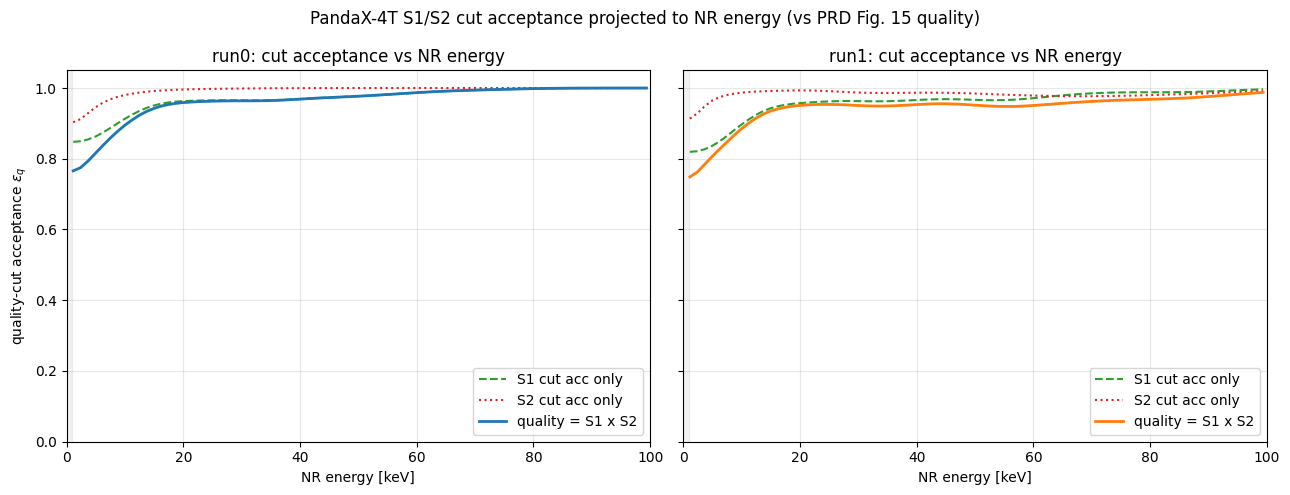

In [3]:
def binned_mean(e, y, edges):
    idx = np.digitize(e, edges) - 1
    ctr = 0.5 * (edges[:-1] + edges[1:])
    m = np.array([y[idx == k].mean() if (idx == k).sum() > 200 else np.nan
                  for k in range(len(ctr))])
    s = np.array([y[idx == k].std() / max((idx == k).sum(), 1)**0.5 if (idx == k).sum() > 200 else np.nan
                  for k in range(len(ctr))])
    return ctr, m, s

edges = np.linspace(E_LO, E_HI, 80)
fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
col = {'run0': 'tab:blue', 'run1': 'tab:orange'}
for j, run in enumerate(['run0', 'run1']):
    e, ca1, ca2 = proj[run]
    c, eff_m, eff_s = binned_mean(e, ca1 * ca2, edges)
    _, s1_m, _ = binned_mean(e, ca1, edges)
    _, s2_m, _ = binned_mean(e, ca2, edges)
    ax[j].plot(c, s1_m, '--', color='tab:green', label='S1 cut acc only')
    ax[j].plot(c, s2_m, ':', color='tab:red', label='S2 cut acc only')
    ax[j].plot(c, eff_m, '-', color=col[run], lw=2, label='quality = S1 x S2')
    ax[j].fill_between(c, eff_m - eff_s, eff_m + eff_s, color=col[run], alpha=0.2)
    # optional overlay of a digitized Fig.15 quality curve, if present
    for fn in (f'pandax4t_{run}_quality.csv', f'pandax4t_{run}_eff_quality.csv'):
        p = os.path.join(DATA, fn)
        if os.path.exists(p):
            q = np.loadtxt(p, delimiter=','); ax[j].plot(q[:,0], q[:,1], 'k.', ms=4, label='Fig.15 quality (digitized)')
            break
    ax[j].set(title=f'{run}: cut acceptance vs NR energy', xlabel='NR energy [keV]',
              ylim=(0, 1.05), xlim=(0, E_HI))
    ax[j].axvspan(0, 1, color='gray', alpha=0.1)
    ax[j].legend(loc='lower right'); ax[j].grid(alpha=0.3)
ax[0].set_ylabel(r'quality-cut acceptance $\epsilon_q$')
fig.suptitle('PandaX-4T S1/S2 cut acceptance projected to NR energy (vs PRD Fig. 15 quality)')
fig.tight_layout(); plt.show()

## Notes
- The projected **quality = S1 x S2** curve rises from threshold and plateaus toward high energy; the **low-energy rolloff is S1-driven** (the S1 cut acceptance map falls off at low $Q_{S1}$, i.e. low energy), with the S2 cut adding a smaller reduction.
- This is the energy-space image of the Fig. 12 maps under the P4-NEST + detector response, and should track the Fig. 15 **quality** curve (not the *total* curve, which additionally folds in reconstruction and ROI efficiencies).
- To overlay the published curve, drop a digitized CSV at `diamx/data/pandax4t_run{0,1}_quality.csv` (energy, acceptance) and re-run.